# Лабораторная работа 2. Наложение и удаление шума на SAR-изображении
**DE_IP_2024 · Task 2**

Задание:
1. Зашумить изображение при помощи шума Гаусса и «постоянного» (импульсного) шума.
2. Протестировать медианный фильтр, фильтр Гаусса, билатеральный фильтр и фильтр нелокальных средних с различными параметрами.
3. Выяснить, какой фильтр показал лучший результат фильтрации шума.

**Про «постоянный шум».** В лекции для второго вида шума используется шум «соль и перец»: часть пикселей принудительно заменяется на постоянные значения 0 (чёрный) и 255 (белый). Именно его я и называю постоянным (импульсным) шумом.

**Метрики качества** (сравниваем очищенное изображение с *чистым оригиналом*):
* **MSE** — средний квадрат разности, меньше — лучше;
* **SSIM** — структурное сходство, ближе к 1 — лучше.

In [1]:
import time
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity, mean_squared_error

## 1. Загрузка изображения

Размер (h, w): (675, 1200) | тип: uint8


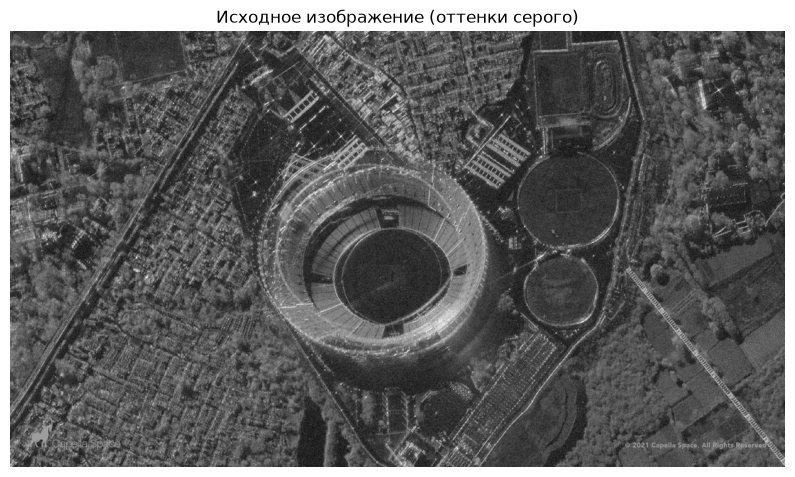

In [2]:
IMAGE_PATH = 'sar_1.png'   # файл лежит в той же папке, что и ноутбук

image = cv2.imread(IMAGE_PATH)
assert image is not None, f'Не удалось загрузить {IMAGE_PATH}: проверьте имя файла и папку'
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

print('Размер (h, w):', image_gray.shape, '| тип:', image_gray.dtype)

plt.figure(figsize=(10, 6))
plt.imshow(image_gray, cmap='gray', vmin=0, vmax=255)
plt.title('Исходное изображение (оттенки серого)')
plt.axis('off')
plt.show()

## 2. Наложение шума

### 2.1. Шум Гаусса
К каждому пикселю добавляется случайное число из нормального распределения $N(0, \sigma^2)$, результат обрезается до [0, 255].

> В лекции шум создавался через `cv2.randn` в массиве `uint8`: отрицательные значения при этом обрезаются до 0, поэтому шум получается односторонним и только осветляет картинку.
> Здесь шум генерируется в `float` и симметричен, поэтому это настоящий гауссов шум с нулевым средним.

### 2.2. Постоянный (импульсный) шум «соль и перец»
Доля `AMOUNT` пикселей заменяется на постоянные значения: половина — на 0 («перец»), половина — на 255 («соль»).

Для воспроизводимости результатов зафиксировано начальное значение генератора случайных чисел.

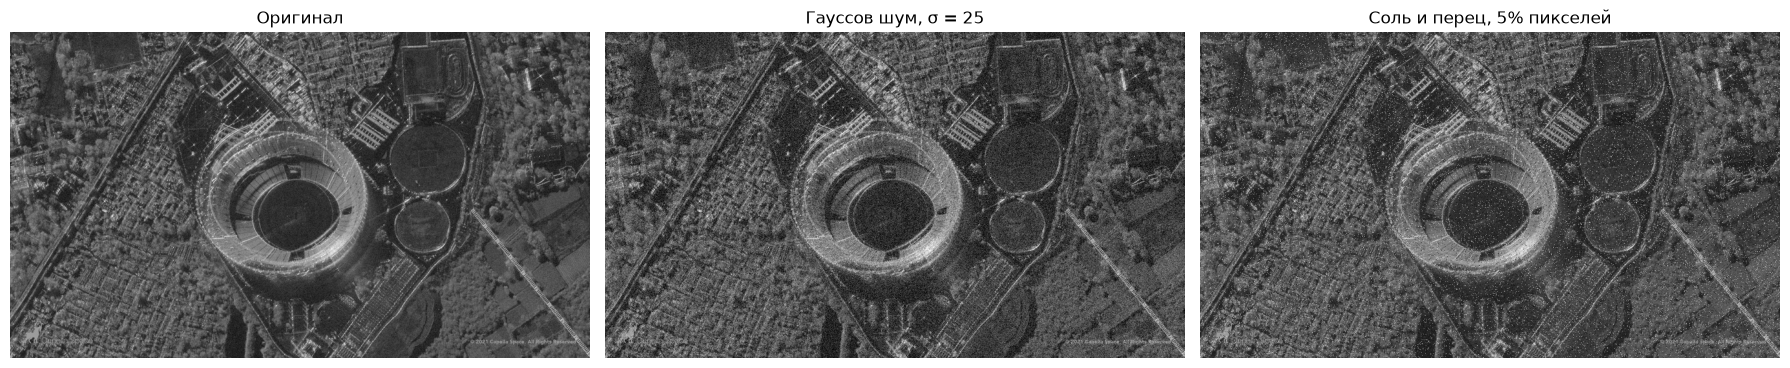

Изображение                        MSE      SSIM
------------------------------------------------
Гауссов шум                      610.6    0.4810
Соль и перец                     981.6    0.4783


In [3]:
rng = np.random.default_rng(42)      # фиксируем seed: результаты повторяются при каждом запуске

# --- Гауссов шум ---
SIGMA = 25
noise_gauss = rng.normal(0, SIGMA, image_gray.shape)
image_noise_gauss = np.clip(image_gray + noise_gauss, 0, 255).astype(np.uint8)

# --- Постоянный (импульсный) шум: соль и перец ---
AMOUNT = 0.05                        # 5% пикселей испорчено
rand = rng.random(image_gray.shape)
image_noise_sp = image_gray.copy()
image_noise_sp[rand < AMOUNT / 2] = 0            # перец
image_noise_sp[rand > 1 - AMOUNT / 2] = 255      # соль


def compare(reference, img):
    """Возвращает (MSE, SSIM) изображения img относительно reference."""
    mse = mean_squared_error(reference.astype(np.float64), img.astype(np.float64))
    ssim = structural_similarity(reference, img, data_range=255)
    return mse, ssim


fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
for ax, (title, img) in zip(axes, [('Оригинал', image_gray),
                                   (f'Гауссов шум, σ = {SIGMA}', image_noise_gauss),
                                   (f'Соль и перец, {AMOUNT * 100:.0f}% пикселей', image_noise_sp)]):
    ax.imshow(img, cmap='gray', vmin=0, vmax=255)
    ax.set_title(title)
    ax.axis('off')
plt.tight_layout()
plt.show()

print(f'{"Изображение":<28}{"MSE":>10}{"SSIM":>10}')
print('-' * 48)
for name, img in [('Гауссов шум', image_noise_gauss), ('Соль и перец', image_noise_sp)]:
    mse, ssim = compare(image_gray, img)
    print(f'{name:<28}{mse:>10.1f}{ssim:>10.4f}')

## 3. Фильтры и их параметры

| Фильтр | Функция OpenCV | Идея | Параметры в тесте |
|---|---|---|---|
| Медианный | `cv2.medianBlur` | заменяет пиксель медианой окна | размер окна 3, 5, 7, 9 |
| Гаусса | `cv2.GaussianBlur` | взвешенное усреднение, веса по Гауссу | размер ядра 3, 5, 7, 9 |
| Билатеральный | `cv2.bilateralFilter` | усреднение с учётом и расстояния, и разницы яркостей (сохраняет границы) | диаметр `d`, `sigmaColor`, `sigmaSpace` |
| Нелокальных средних | `cv2.fastNlMeansDenoising` | усредняет пиксели с *похожими окрестностями* по всему окну поиска | сила фильтра `h`, окно шаблона и окно поиска |

In [4]:
# Каждая конфигурация: (семейство фильтров, подпись параметров, функция img -> img)
configs = []

for k in [3, 5, 7, 9]:
    configs.append(('Медианный', f'k = {k}',
                    lambda img, k=k: cv2.medianBlur(img, k)))

for k in [3, 5, 7, 9]:
    configs.append(('Гаусса', f'ядро {k}×{k}',
                    lambda img, k=k: cv2.GaussianBlur(img, (k, k), 0)))

for d, sc, ss in [(5, 25, 25), (9, 50, 50), (9, 75, 75), (9, 150, 150)]:
    configs.append(('Билатеральный', f'd={d}, σc={sc}, σs={ss}',
                    lambda img, d=d, sc=sc, ss=ss: cv2.bilateralFilter(img, d, sc, ss)))

for h, t, s in [(15, 7, 21), (20, 7, 21), (30, 7, 21), (20, 5, 15)]:
    configs.append(('Нелокальных средних', f'h={h}, шаблон={t}, поиск={s}',
                    lambda img, h=h, t=t, s=s: cv2.fastNlMeansDenoising(
                        img, None, h=h, templateWindowSize=t, searchWindowSize=s)))

print('Всего конфигураций фильтров:', len(configs))

Всего конфигураций фильтров: 16


In [5]:
def run_experiments(noisy):
    """Применяет все фильтры к зашумлённому изображению и считает метрики относительно оригинала."""
    results = []
    for family, label, func in configs:
        t0 = time.perf_counter()
        out = func(noisy)
        elapsed = time.perf_counter() - t0
        mse, ssim = compare(image_gray, out)
        results.append({'family': family, 'label': label, 'img': out,
                        'mse': mse, 'ssim': ssim, 'time': elapsed})
    return results


def print_table(results, title):
    print(title)
    print(f'{"Фильтр":<22}{"Параметры":<30}{"MSE":>9}{"SSIM":>9}{"Время, с":>10}')
    print('-' * 80)
    prev = None
    for r in results:
        if prev is not None and r['family'] != prev:
            print()
        prev = r['family']
        print(f'{r["family"]:<22}{r["label"]:<30}{r["mse"]:>9.1f}{r["ssim"]:>9.4f}{r["time"]:>10.3f}')


# Увеличенный фрагмент (ряды трибун стадиона) — на нём лучше видна разница между фильтрами
ROI = (slice(230, 350), slice(430, 640))


def show_results_grid(results, noisy, noise_title):
    """Сетка: 1-я строка — оригинал и зашумлённое, затем по строке на каждый фильтр (фрагмент)."""
    families = list(dict.fromkeys(r['family'] for r in results))
    fig, axes = plt.subplots(1 + len(families), 4, figsize=(16, 3.1 * (1 + len(families))))
    for ax in axes.ravel():
        ax.axis('off')

    axes[0, 0].imshow(image_gray[ROI], cmap='gray', vmin=0, vmax=255)
    axes[0, 0].set_title('Оригинал')
    axes[0, 1].imshow(noisy[ROI], cmap='gray', vmin=0, vmax=255)
    mse, ssim = compare(image_gray, noisy)
    axes[0, 1].set_title(f'{noise_title}\nMSE={mse:.0f}, SSIM={ssim:.3f}', fontsize=9)

    for row, fam in enumerate(families, start=1):
        for col, r in enumerate([x for x in results if x['family'] == fam]):
            axes[row, col].imshow(r['img'][ROI], cmap='gray', vmin=0, vmax=255)
            axes[row, col].set_title(f'{fam}\n{r["label"]}\nMSE={r["mse"]:.0f}, SSIM={r["ssim"]:.3f}', fontsize=9)
    plt.tight_layout()
    plt.show()

## 4. Шум Гаусса: результаты фильтрации

In [6]:
results_gauss = run_experiments(image_noise_gauss)
print_table(results_gauss, f'Гауссов шум (σ = {SIGMA}): MSE и SSIM относительно оригинала')

Гауссов шум (σ = 25): MSE и SSIM относительно оригинала
Фильтр                Параметры                           MSE     SSIM  Время, с
--------------------------------------------------------------------------------
Медианный             k = 3                             210.3   0.6371     0.001
Медианный             k = 5                             240.0   0.5615     0.001
Медианный             k = 7                             285.6   0.4833     0.022
Медианный             k = 9                             331.0   0.4151     0.022

Гаусса                ядро 3×3                          150.7   0.7234     0.000
Гаусса                ядро 5×5                          156.9   0.7060     0.000
Гаусса                ядро 7×7                          188.8   0.6481     0.000
Гаусса                ядро 9×9                          214.4   0.6023     0.000

Билатеральный         d=5, σc=25, σs=25                 303.3   0.6032     0.005
Билатеральный         d=9, σc=50, σs=50            

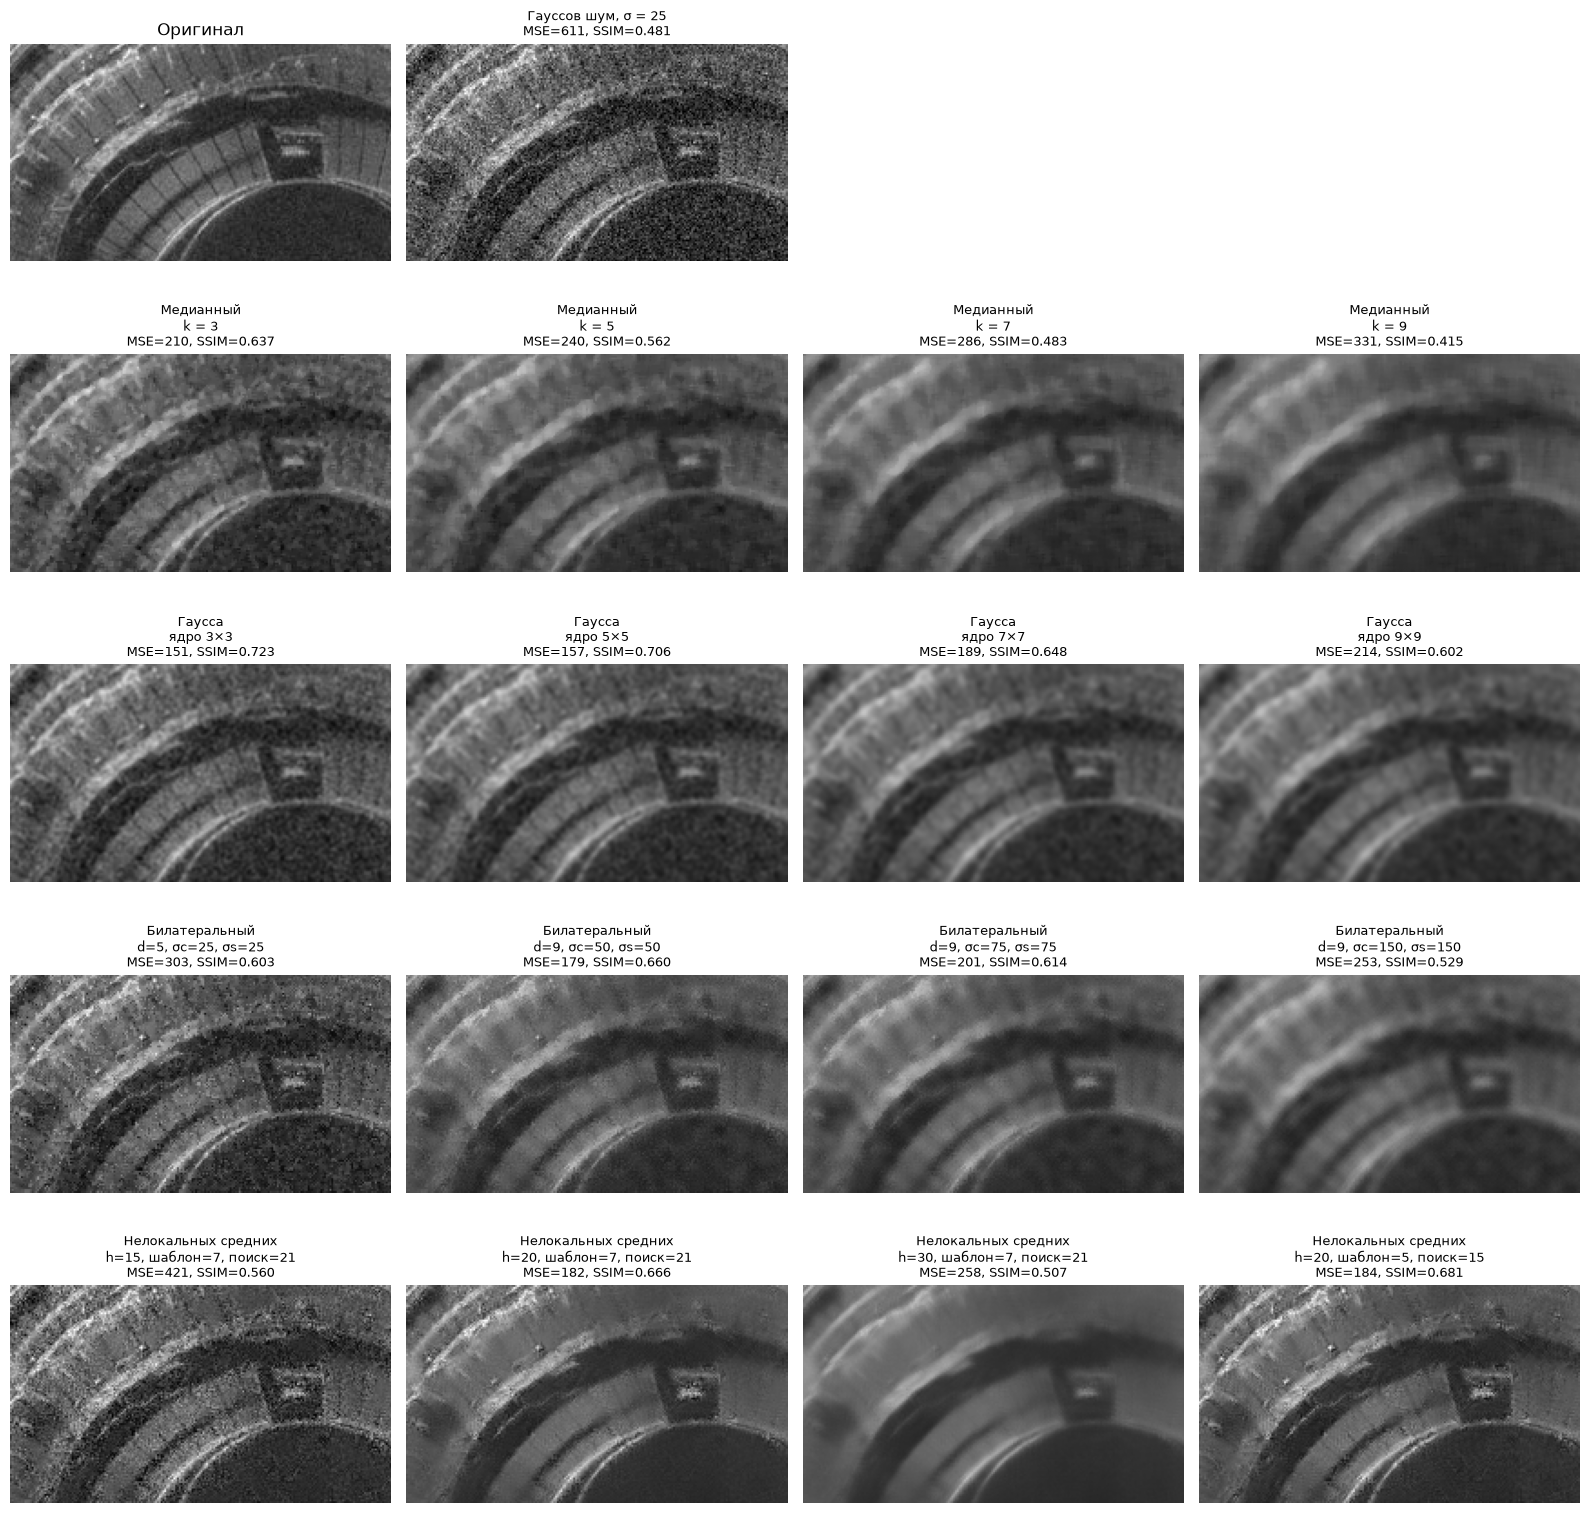

In [7]:
show_results_grid(results_gauss, image_noise_gauss, f'Гауссов шум, σ = {SIGMA}')

## 5. Постоянный шум «соль и перец»: результаты фильтрации

In [8]:
results_sp = run_experiments(image_noise_sp)
print_table(results_sp, f'Соль и перец ({AMOUNT * 100:.0f}%): MSE и SSIM относительно оригинала')

Соль и перец (5%): MSE и SSIM относительно оригинала
Фильтр                Параметры                           MSE     SSIM  Время, с
--------------------------------------------------------------------------------
Медианный             k = 3                             100.1   0.8111     0.000
Медианный             k = 5                             196.1   0.6312     0.001
Медианный             k = 7                             261.2   0.5216     0.020
Медианный             k = 9                             315.0   0.4417     0.022

Гаусса                ядро 3×3                          215.2   0.6709     0.000
Гаусса                ядро 5×5                          197.9   0.6627     0.000
Гаусса                ядро 7×7                          217.5   0.6174     0.000
Гаусса                ядро 9×9                          238.8   0.5783     0.000

Билатеральный         d=5, σc=25, σs=25                 994.0   0.4088     0.004
Билатеральный         d=9, σc=50, σs=50               

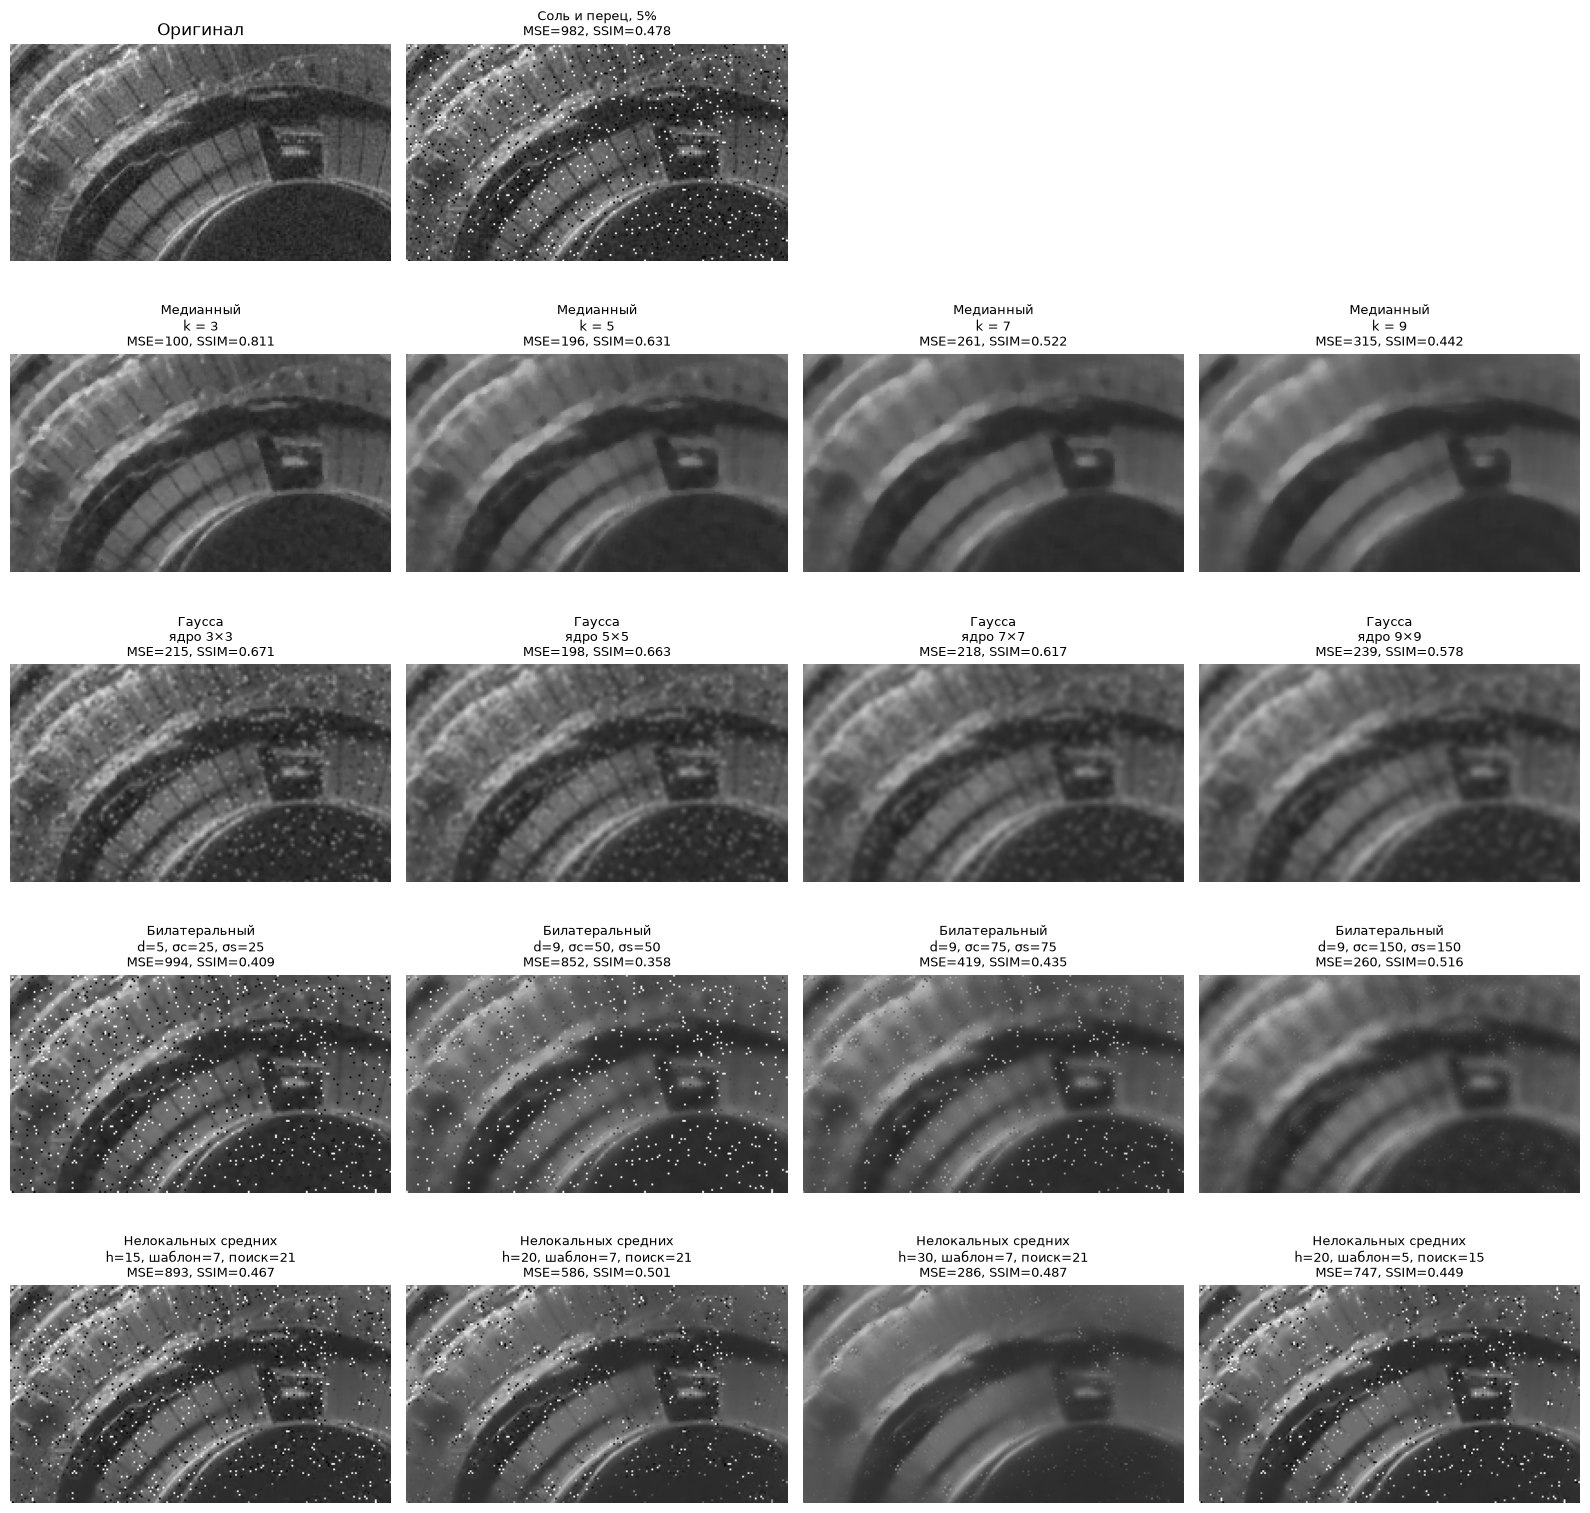

In [9]:
show_results_grid(results_sp, image_noise_sp, f'Соль и перец, {AMOUNT * 100:.0f}%')

## 6. Какой фильтр лучше?
Для каждого семейства фильтров берём лучшую конфигурацию (по SSIM) и сравниваем семейства между собой.

In [10]:
def best_per_family(results):
    best = {}
    for r in results:
        if r['family'] not in best or r['ssim'] > best[r['family']]['ssim']:
            best[r['family']] = r
    return best


for title, results in [(f'Гауссов шум (σ = {SIGMA})', results_gauss),
                       (f'Соль и перец ({AMOUNT * 100:.0f}%)', results_sp)]:
    best = best_per_family(results)
    ranking = sorted(best.values(), key=lambda r: r['ssim'], reverse=True)
    print(title)
    print(f'{"Место":<7}{"Фильтр":<22}{"Лучшие параметры":<30}{"MSE":>9}{"SSIM":>9}{"Время, с":>10}')
    print('-' * 87)
    for place, r in enumerate(ranking, start=1):
        print(f'{place:<7}{r["family"]:<22}{r["label"]:<30}{r["mse"]:>9.1f}{r["ssim"]:>9.4f}{r["time"]:>10.3f}')
    print(f'--> Лучший по SSIM: {ranking[0]["family"]} ({ranking[0]["label"]})')
    best_mse = min(best.values(), key=lambda r: r['mse'])
    print(f'--> Лучший по MSE : {best_mse["family"]} ({best_mse["label"]})')
    print()

Гауссов шум (σ = 25)
Место  Фильтр                Лучшие параметры                    MSE     SSIM  Время, с
---------------------------------------------------------------------------------------
1      Гаусса                ядро 3×3                          150.7   0.7234     0.000
2      Нелокальных средних   h=20, шаблон=5, поиск=15          184.4   0.6812     0.064
3      Билатеральный         d=9, σc=50, σs=50                 178.8   0.6605     0.009
4      Медианный             k = 3                             210.3   0.6371     0.001
--> Лучший по SSIM: Гаусса (ядро 3×3)
--> Лучший по MSE : Гаусса (ядро 3×3)

Соль и перец (5%)
Место  Фильтр                Лучшие параметры                    MSE     SSIM  Время, с
---------------------------------------------------------------------------------------
1      Медианный             k = 3                             100.1   0.8111     0.000
2      Гаусса                ядро 3×3                          215.2   0.6709     0.000
3   

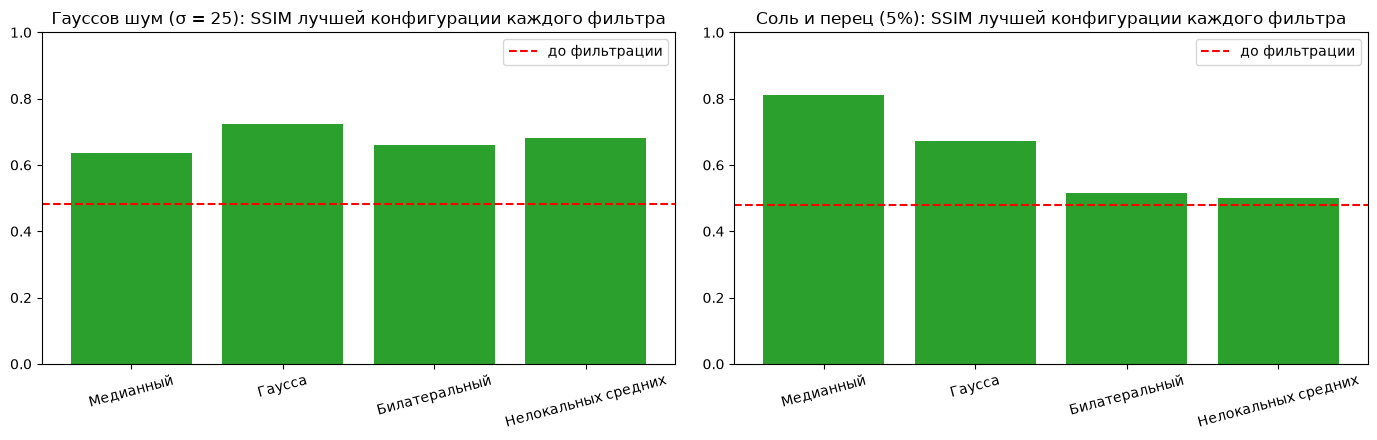

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for ax, (title, results) in zip(axes, [(f'Гауссов шум (σ = {SIGMA})', results_gauss),
                                       (f'Соль и перец ({AMOUNT * 100:.0f}%)', results_sp)]):
    best = best_per_family(results)
    names = list(best.keys())
    ax.bar(names, [best[n]['ssim'] for n in names], color='tab:green')
    ax.axhline(compare(image_gray, image_noise_gauss if 'Гаусс' in title else image_noise_sp)[1],
               color='red', linestyle='--', label='до фильтрации')
    ax.set_title(f'{title}: SSIM лучшей конфигурации каждого фильтра')
    ax.set_ylim(0, 1)
    ax.tick_params(axis='x', rotation=15)
    ax.legend()
plt.tight_layout()
plt.show()

## Выводы
Сравнение сделано относительно чистого оригинала; шум: Гаусс σ = 25 (до фильтрации MSE ≈ 610, SSIM ≈ 0.48) и «соль и перец» 5% (MSE ≈ 983, SSIM ≈ 0.48).

**Шум Гаусса.** Лучший результат дал фильтр Гаусса 3×3 (MSE ≈ 151, SSIM ≈ 0.72). Следом идут нелокальные средние (h = 20, шаблон 5, поиск 15: SSIM ≈ 0.68), билатеральный (d = 9, σ = 50: SSIM ≈ 0.66) и медианный с окном 3 (SSIM ≈ 0.63).

**Постоянный шум (соль и перец).** С большим отрывом лучший — медианный фильтр с окном 3 (MSE ≈ 101, SSIM ≈ 0.81). Фильтр Гаусса размазывает выбросы по соседним пикселям (SSIM ≈ 0.67). Билатеральный фильтр и нелокальные средние справляются плохо (SSIM ≈ 0.51 и ≈ 0.50): белые и чёрные точки сильно отличаются от соседей по яркости, поэтому эти фильтры принимают их за границы или непохожие участки и сохраняют.

**Общий вывод.** Универсально лучшего фильтра нет, выбор зависит от типа шума: для импульсного шума — медианный фильтр, для гауссова — линейное сглаживание (Гаусса) с небольшим ядром.

**Наблюдения по параметрам.**
* Чем больше окно (медианный, Гаусса), тем сильнее шум подавляется, но тем больше теряются детали, поэтому качество падает; лучшими оказались самые маленькие из проверенных окон (3×3), то есть оптимум может лежать ещё в сторону более слабого сглаживания.
* У нелокальных средних параметр `h` критичен: при h = 15 фильтр почти не убирает шум, при h = 30 изображение чрезмерно размыто, а лучше всего работает h ≈ σ шума.
* Нелокальные средние на порядок-два медленнее остальных (≈ 0.4–0.7 с против ≈ 0.01 с), а выигрыша по качеству здесь не дали. Вероятная причина: SAR-снимок сам по себе содержит мелкую зернистую текстуру, и любое сильное сглаживание уничтожает часть реальных деталей.
* Результаты зависят от уровня шума, начального значения генератора случайных чисел и выбранной метрики; для других σ лучшие параметры будут другими.